In [1]:
import joblib
mdl = joblib.load("./models/reviews/baseline_model.pkl")
print(type(mdl))
print(mdl)

/home/lesia/DS/projects/phase 2 week 3 var 2/nlp_lora/venv/lib/python3.10/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.8.0 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/lesia/DS/projects/phase 2 week 3 var 2/nlp_lora/venv/lib/python3.10/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.8.0 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/lesia/DS/projects/phase 2 week 3 var 2/nlp_lora/venv/lib/python3.10/site-packages/sklearn/base.py:348: Incons

<class 'sklearn.pipeline.Pipeline'>


AttributeError: 'LogisticRegression' object has no attribute 'multi_class'

In [1]:
!nvidia-smi

Sat Feb 28 15:49:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.195.03             Driver Version: 570.195.03     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4090        On  |   00000000:01:00.0 Off |                  Off |
|  0%   34C    P8             26W /  450W |       1MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install mplcyberpunk


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [3]:
import os
import numpy as np
import pandas as pd
import json

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import transformers

import re
import time
import joblib
import html

from tqdm import tqdm

from transformers import BertTokenizer, AutoTokenizer, AutoModelForSequenceClassification
from collections import Counter
from transformers import BertTokenizer, BertModel, BertConfig, AutoModel
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, classification_report, precision_recall_fscore_support, log_loss

import mplcyberpunk
plt.style.use("cyberpunk")


/workspace/runpod_project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df = pd.read_json('data/healthcare_facilities_reviews.jsonl', lines=True)
df.head()

,review_id,category,title,content,sentiment,source_url
0,0,Поликлиники стоматологические,Классный мастер,Огромное спасибо за чудесное удаление двух зуб...,positive,http://www.spr.ru/forum_vyvod.php?id_tema=2727539
1,1,Поликлиники стоматологические,Замечательный врач,Хочу выразить особую благодарность замечательн...,positive,http://www.spr.ru/forum_vyvod.php?id_tema=2302877
2,2,Поликлиники стоматологические,Благодарность работникам рентгена,Добрый вечер! Хотелось бы поблагодарить сотруд...,positive,http://www.spr.ru/forum_vyvod.php?id_tema=2815031
3,3,Поликлиники стоматологические,Доктор Рабинович,Женщины советского образца в регистратуре не и...,negative,http://www.spr.ru/forum_vyvod.php?id_tema=3443161
4,4,Поликлиники стоматологические,Есть кому сказать спасибо,У меня с детства очень плохие зубы (тонкая и х...,positive,http://www.spr.ru/forum_vyvod.php?id_tema=2592430


In [5]:
# from google.colab import drive
# drive.mount('/content/drive')

In [6]:
# df = pd.read_json('/content/drive/MyDrive/healthcare_facilities_reviews.jsonl', lines=True)
# df.head()

In [7]:
df.isnull().sum()

review_id     0
category      0
title         0
content       0
sentiment     0
source_url    0
dtype: int64

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70597 entries, 0 to 70596
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   review_id   70597 non-null  int64
 1   category    70597 non-null  str  
 2   title       70597 non-null  str  
 3   content     70597 non-null  str  
 4   sentiment   70597 non-null  str  
 5   source_url  70597 non-null  str  
dtypes: int64(1), str(5)
memory usage: 3.2 MB


In [9]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [10]:
results = []

In [11]:
def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""

    # HTML
    text = re.sub(r'<.*?>', ' ', text)

    # URL
    text = re.sub(r'http[s]?://\S+|www\.\S+', ' ', text)

    # email
    text = re.sub(r'\S+@\S+\.\S+', ' ', text)

    # lower
    text = text.lower()

    # убрать мусор, сохранить пунктуацию !?.,…
    text = re.sub(r'[^а-яА-ЯёЁa-zA-Z0-9!?.,…\s-]', ' ', text)

    # !!! → !
    text = re.sub(r'!{2,}', '!', text)

    # ??? → ?
    text = re.sub(r'\?{2,}', '?', text)

    # пробелы
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [12]:
df['cleaned_reviews'] = df['content'].astype(str).apply(clean_text)

In [13]:
df[['content', 'cleaned_reviews']].head()

,content,cleaned_reviews
0,Огромное спасибо за чудесное удаление двух зуб...,огромное спасибо за чудесное удаление двух зуб...
1,Хочу выразить особую благодарность замечательн...,хочу выразить особую благодарность замечательн...
2,Добрый вечер! Хотелось бы поблагодарить сотруд...,добрый вечер! хотелось бы поблагодарить сотруд...
3,Женщины советского образца в регистратуре не и...,женщины советского образца в регистратуре не и...
4,У меня с детства очень плохие зубы (тонкая и х...,у меня с детства очень плохие зубы тонкая и хр...


In [14]:
dist = df['sentiment'].value_counts().reset_index()
dist.columns = ['label', 'count']
dist['percent'] = dist['count'] / dist['count'].sum() * 100
dist

,label,count,percent
0,positive,41419,58.669632
1,negative,29178,41.330368


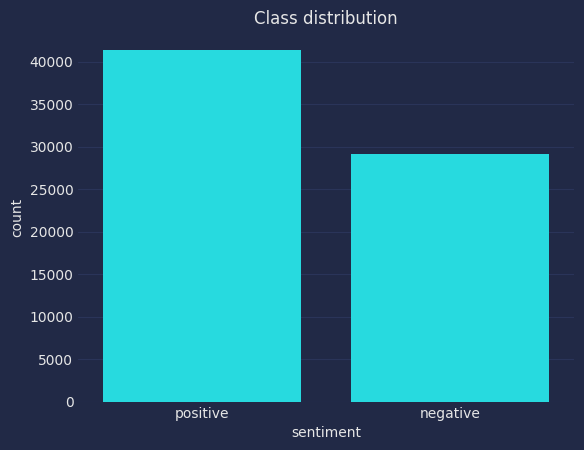

In [15]:
sns.countplot(x=df['sentiment'])
plt.title("Class distribution")
plt.show()

In [16]:
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})   # поскольку логрег работает с числовыми метками делаем бинарную кодировку

In [17]:
# X, y
X = df['cleaned_reviews']
y = df['sentiment']

# 1. Train + Temp (80% / 20%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 2. Temp → Valid + Test (10% / 10%)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", len(X_train), "Valid:", len(X_valid), "Test:", len(X_test))

Train: 56477 Valid: 7060 Test: 7060


In [18]:
log_clf = Pipeline([
    ("tfidf", TfidfVectorizer(          # TF-IDF превращает текст в числовой вектор.
        ngram_range=(1, 2),                # даёт униграммы и биграммы → больше контекста
        max_features=50000,
        min_df=3
    )),
    ("clf", LogisticRegression(
        max_iter=2000,
        solver="saga",
        class_weight="balanced",
        n_jobs=-1
    ))
])


#  Время обучения
t0 = time.time()
log_clf.fit(X_train, y_train)
train_time_sec = time.time() - t0
train_time_ms = train_time_sec * 1000

# Метрики на train
y_train_pred = log_clf.predict(X_train)
y_train_prob = log_clf.predict_proba(X_train)

train_acc = accuracy_score(y_train, y_train_pred)
f1_train = f1_score(y_train, y_train_pred, average="macro")
train_loss = log_loss(y_train, y_train_prob)


# VALIDATION INFERENCE (per sample)
t0 = time.time()
y_val_pred = log_clf.predict(X_valid)
infer_time_sec = time.time() - t0
infer_time_ms_total = infer_time_sec * 1000
infer_time_ms_per_sample = infer_time_ms_total / len(X_valid)

y_val_prob = log_clf.predict_proba(X_valid)


#  Метрики validation
val_acc = accuracy_score(y_valid, y_val_pred)
f1_val = f1_score(y_valid, y_val_pred, average="macro")
val_loss = log_loss(y_valid, y_val_prob)


# CONFUSION MATRIX
cm_logreg = confusion_matrix(y_valid, y_val_pred)


# OUTPUT
print(f"Train time (sec): {train_time_sec:.2f}")
print(f"Inference time per sample (ms): {infer_time_ms_per_sample:.4f}")

print("Train Accuracy:", train_acc)
print("Train F1-macro:", f1_train)
print("Train Log-loss:", train_loss)

print("Valid Accuracy:", val_acc)
print("Valid F1-macro:", f1_val)
print("Valid Log-loss:", val_loss)

print("Confusion Matrix (Valid):")
print(cm_logreg)

/workspace/runpod_project/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Train time (sec): 17.50
Inference time per sample (ms): 0.0815
Train Accuracy: 0.9634364431538502
Train F1-macro: 0.9625329913943121
Train Log-loss: 0.14884579579472304
Valid Accuracy: 0.946600566572238
Valid F1-macro: 0.945357130942452
Valid Log-loss: 0.171071994968024
Confusion Matrix (Valid):
[[2809  109]
 [ 268 3874]]


In [19]:
baseline_results = {
    "model": "LogReg TF-IDF",
    "train_time_sec": float(train_time_sec),
    "train_time_ms": float(train_time_ms),
    "infer_time_ms_per_sample": float(infer_time_ms_per_sample),
    "train_acc": float(train_acc),
    "train_f1": float(f1_train),
    "train_logloss": float(train_loss),
    "val_acc": float(val_acc),
    "val_f1": float(f1_val),
    "val_logloss": float(val_loss),
    "confusion_matrix": cm_logreg.tolist()
}

with open("logreg_results.json", "w") as f:
    json.dump(baseline_results, f, indent=4)

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_cm(y_true, y_pred, title="Confusion matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    fig, ax = plt.subplots(figsize=(4,4))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Negative", "Positive"]
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        values_format="d",
        colorbar=True
    )

    # убираем внутренние линии
    ax.grid(False)

    # убираем рамки вокруг ячеек
    for spine in ax.spines.values():
        spine.set_visible(False)

    # убираем интерполяцию (главное!)
    for im in ax.get_images():
        im.set_interpolation("nearest")

    plt.title(title)
    plt.tight_layout()
    plt.show()

    return cm

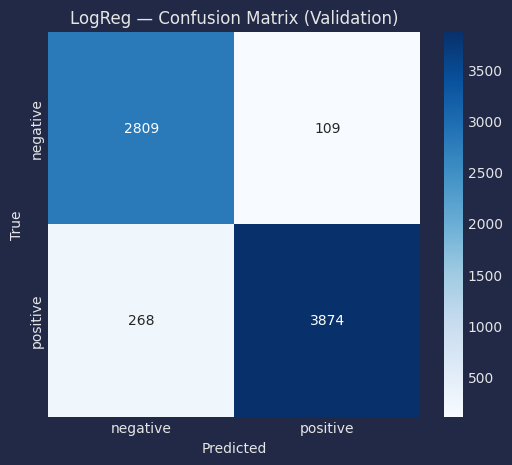

In [21]:
cm = confusion_matrix(y_valid, y_val_pred, labels=[0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["negative", "positive"],
    yticklabels=["negative", "positive"]
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("LogReg — Confusion Matrix (Validation)")
plt.show()

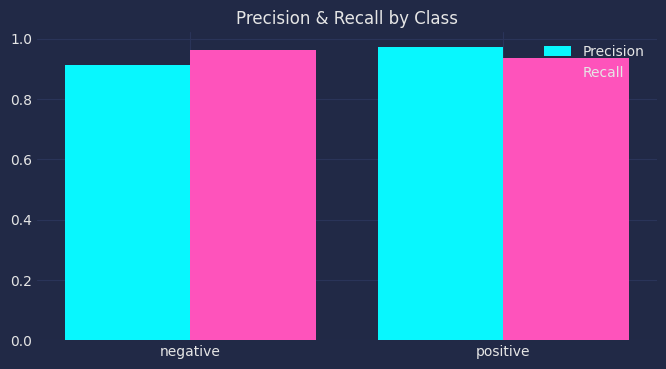

In [22]:
prec, rec, f1_cls, _ = precision_recall_fscore_support(
    y_valid, y_val_pred, labels=[0, 1]
)

plt.figure(figsize=(8, 4))
x = np.arange(2)
plt.bar(x - 0.2, prec, width=0.4, label="Precision")
plt.bar(x + 0.2, rec, width=0.4, label="Recall")
plt.xticks(x, ["negative", "positive"])
plt.title("Precision & Recall by Class")
plt.legend()
plt.show()

In [23]:
joblib.dump(log_clf, "baseline_model.pkl")
print("\nSaved baseline_model.pkl")

results.append({
    "model": "TFIDF_LogReg",
    "train_loss": train_loss,
    "train_f1": f1_train,
    "train_acc": train_acc,
    "val_loss": val_loss,
    "val_f1": f1_val,
    "val_acc": val_acc,
    "infer_time_sec_per_sample": infer_time_sec,
    "train_time_sec": train_time_sec
})

import json
with open("baseline_results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print("Saved baseline_results.json")


Saved baseline_model.pkl
Saved baseline_results.json


In [24]:
clf = log_clf.named_steps["clf"]
tfidf = log_clf.named_steps["tfidf"]

n_features = len(tfidf.get_feature_names_out())
n_params = clf.coef_.size + clf.intercept_.size

print("TF-IDF vocabulary size:", n_features)
print("Logistic Regression parameters:", n_params)

TF-IDF vocabulary size: 50000
Logistic Regression parameters: 50001


In [25]:
def predict_review_baseline(text, model, clean_fn):

    # очистка текста
    cleaned = clean_fn(text)

    # инференс
    t0 = time.time()
    prob = model.predict_proba([cleaned])[0, 1]    # вероятность positive
    label = int(prob >= 0.5)
    infer_ms = (time.time() - t0) * 1000

    return label, float(prob), infer_ms

In [26]:
example_text = "рекомендую эту клинику"

label, prob, infer_ms = predict_review_baseline(
    example_text,
    log_clf,       # TF-IDF + LogisticRegression pipeline
    clean_text     # функция очистки
)

print(f"Text: {example_text}")
print(f"Prob(positive) = {prob:.4f}, label = {label}, infer = {infer_ms:.2f} sec")

Text: рекомендую эту клинику
Prob(positive) = 0.8275, label = 1, infer = 1.14 sec


# LSTM

In [27]:
df = pd.read_json('data/healthcare_facilities_reviews.jsonl', lines=True)
df.head()

,review_id,category,title,content,sentiment,source_url
0,0,Поликлиники стоматологические,Классный мастер,Огромное спасибо за чудесное удаление двух зуб...,positive,http://www.spr.ru/forum_vyvod.php?id_tema=2727539
1,1,Поликлиники стоматологические,Замечательный врач,Хочу выразить особую благодарность замечательн...,positive,http://www.spr.ru/forum_vyvod.php?id_tema=2302877
2,2,Поликлиники стоматологические,Благодарность работникам рентгена,Добрый вечер! Хотелось бы поблагодарить сотруд...,positive,http://www.spr.ru/forum_vyvod.php?id_tema=2815031
3,3,Поликлиники стоматологические,Доктор Рабинович,Женщины советского образца в регистратуре не и...,negative,http://www.spr.ru/forum_vyvod.php?id_tema=3443161
4,4,Поликлиники стоматологические,Есть кому сказать спасибо,У меня с детства очень плохие зубы (тонкая и х...,positive,http://www.spr.ru/forum_vyvod.php?id_tema=2592430


In [28]:
# df = pd.read_json('/content/drive/MyDrive/healthcare_facilities_reviews.jsonl', lines=True)
# df.head()

In [29]:
def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""

    # HTML
    text = re.sub(r'<.*?>', ' ', text)

    # URL
    text = re.sub(r'http[s]?://\S+|www\.\S+', ' ', text)

    # emails
    text = re.sub(r'\S+@\S+\.\S+', ' ', text)

    # lower
    text = text.lower()

    # оставляем все буквы, цифры, пунктуацию, эмодзи
    text = re.sub(r'[^а-яёa-z0-9!?.,;:()\'"«»\-\s\U0001F300-\U0001FAFF]', ' ', text)

    # пробелы
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [30]:
df['cleaned_reviews'] = df['content'].astype(str).apply(clean_text)

In [31]:
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

count    70597.000000
mean        93.583679
std         93.600686
min          1.000000
25%         38.000000
50%         65.000000
75%        113.000000
max        865.000000
Name: cleaned_reviews, dtype: float64
95% отзывов имеют длину меньше или равную: 267.0


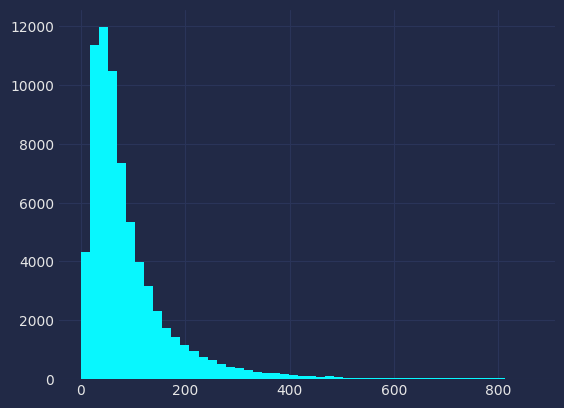

In [32]:
# Считаем длину каждого отзыва (в словах)
lengths = df['cleaned_reviews'].apply(lambda x: len(x.split()))

# Смотрим статистику
print(lengths.describe())

# Находим 95-й перцентиль
percentile_95 = lengths.quantile(0.95)
print(f"95% отзывов имеют длину меньше или равную: {percentile_95}")

# Рисуем гистограмму
plt.hist(lengths, bins=50)
plt.show()

In [33]:
# 1. строим корпус и считаем частоты
corpus = [w for text in df['cleaned_reviews'] for w in text.split()]
word_counts = Counter(corpus)

# 2. строим словарь
sorted_words = word_counts.most_common(15000)
vocab = [w for w, c in sorted_words if c >= 5]  # отсечение редких слов
vocab_to_int = {w: i + 1 for i, w in enumerate(vocab)}  # 0 — PAD

# 3. сохраняем словарь
with open("vocab_LSTM.json", "w", encoding="utf8") as f:
    json.dump(vocab_to_int, f, ensure_ascii=False)

# 4. кодируем отзывы
reviews_int = []
for text in df['cleaned_reviews']:
    review = [vocab_to_int[w] for w in text.split() if w in vocab_to_int]
    reviews_int.append(review)

In [34]:
def padding_tail(reviews, seq_len=200):
    features = np.zeros((len(reviews), seq_len), dtype=int)
    for i, r in enumerate(reviews):
        if len(r) <= seq_len:
            features[i] = np.hstack([np.zeros(seq_len - len(r)), r])
        else:
            features[i] = r[-seq_len:]
    return features

SEQ_LEN = 200
features = padding_tail(reviews_int, SEQ_LEN)
labels = df['sentiment'].values

In [35]:
class LSTMDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences        # список списков индексов
        self.labels = labels              # список 0/1

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = torch.tensor(self.sequences[idx], dtype=torch.long)   
        y = torch.tensor(self.labels[idx], dtype=torch.long)      
        return x, y

In [36]:
X_train, X_valid, y_train, y_valid = train_test_split(
    features, labels, test_size=0.2, random_state=1
)

train_ds = LSTMDataset(X_train, y_train)
valid_ds = LSTMDataset(X_valid, y_valid)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, drop_last=True)
valid_loader = DataLoader(valid_ds, batch_size=128, shuffle=False)

In [37]:
class LSTMNet(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=128, n_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.dropout = nn.Dropout(0.2)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=n_layers,
            batch_first=True
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)        
        )

    def forward(self, x):
        x = self.embedding(x)
        x = self.dropout(x)
        out, (h, c) = self.lstm(x)
        logits = self.fc(h[-1])
        return logits.squeeze(1)   

In [38]:
def accuracy(logits, y):
    preds = (torch.sigmoid(logits) >= 0.5).long()
    return (preds == y).float().mean()


def train_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss, total_acc = 0, 0
    all_y_true, all_y_pred = [], []

    for X, y in loader:
        X = X.to(device)
        y = y.to(device).long()             

        optimizer.zero_grad()

        logits = model(X)                   
        loss = criterion(logits, y.float()) 

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).long()

        acc = (preds == y).float().mean()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        total_loss += loss.item()
        total_acc += acc.item()

        all_y_true.extend(y.cpu().numpy())
        all_y_pred.extend(preds.cpu().numpy())

    f1 = f1_score(all_y_true, all_y_pred, average='macro')

    return total_loss / len(loader), total_acc / len(loader), f1


def valid_epoch(model, loader, criterion, device):
    model.eval()

    total_loss, total_acc = 0, 0
    all_y_true, all_y_pred = [], []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            y = y.to(device).long()        

            logits = model(X)              
            loss = criterion(logits, y.float())

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).long()

            acc = (preds == y).float().mean()

            total_loss += loss.item()
            total_acc += acc.item()

            all_y_true.extend(y.cpu().numpy())
            all_y_pred.extend(preds.cpu().numpy())

    f1 = f1_score(all_y_true, all_y_pred, average='macro')

    return total_loss / len(loader), total_acc / len(loader), f1

In [39]:
class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.best_loss = float('inf')
        self.counter = 0
        self.best_state = None

    def step(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.best_state = {k: v.cpu() for k, v in model.state_dict().items()}
            self.counter = 0
            return False  
        else:
            self.counter += 1
            return self.counter >= self.patience  

In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

VOCAB_SIZE = len(vocab_to_int) + 1
model = LSTMNet(VOCAB_SIZE).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=0.0001)

In [41]:
# === PARAM COUNT ===
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 1067713
Trainable parameters: 1067713


In [42]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

In [ ]:
EPOCHS = 30
early = EarlyStopping(patience=3)

train_losses, valid_losses = [], []
train_accs, valid_accs = [], []
train_f1s, valid_f1s = [], []
infer_times = []

epoch_times_lstm = []
total_time_lstm = 0.0  # ms

best_val_loss = float("inf")
best_model_path = "best_lstm_model.pt"
best_metrics = None

for epoch in range(1, EPOCHS + 1):

    t_epoch_start = time.time()

    # --- TRAIN ---
    t_loss, t_acc, t_f1 = train_epoch(model, train_loader, criterion, optimizer, device)

    # --- VALID ---
    v_loss, v_acc, v_f1 = valid_epoch(model, valid_loader, criterion, device)

    train_losses.append(t_loss)
    valid_losses.append(v_loss)
    train_accs.append(t_acc)
    valid_accs.append(v_acc)
    train_f1s.append(t_f1)
    valid_f1s.append(v_f1)

    scheduler.step(v_loss)

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        torch.save(model.state_dict(), best_model_path)
        best_metrics = {
            "epoch": epoch,
            "train_loss": float(t_loss),
            "train_acc": float(t_acc),
            "train_f1": float(t_f1),
            "val_loss": float(v_loss),
            "val_acc": float(v_acc),
            "val_f1": float(v_f1),
        }

    # --- INFERENCE TIME ---
    t0 = time.time()
    with torch.no_grad():
        for Xb, _ in valid_loader:
            Xb = Xb.to(device)
            _ = model(Xb)

    infer_time_ms = (time.time() - t0) * 1000 / len(X_valid)
    infer_times.append(infer_time_ms)

    # --- EPOCH TIME ---
    epoch_time_ms = (time.time() - t_epoch_start) * 1000.0
    epoch_times_lstm.append(epoch_time_ms)
    total_time_lstm += epoch_time_ms
    total_time_lstm_sec = total_time_lstm / 1000.0
    
    print(
        f"Epoch {epoch:02d} | "
        f"TrainLoss={t_loss:.4f} Acc={t_acc:.4f} F1={t_f1:.4f} | "
        f"ValidLoss={v_loss:.4f} Acc={v_acc:.4f} F1={v_f1:.4f} | "
        f"Infer={infer_time_ms:.3f} ms/sample | "
        f"EpochTime={epoch_time_ms/1000:.2f} s | "
        f"LR={optimizer.param_groups[0]['lr']}"
    )

    if early.step(v_loss, model):
        print("Early stopping triggered.")
        break

Epoch 01 | TrainLoss=0.4798 Acc=0.7629 F1=0.7514 | ValidLoss=0.3673 Acc=0.8377 F1=0.8359 | Infer=0.010 ms/sample | EpochTime=4.65 s | LR=0.0005
Epoch 02 | TrainLoss=0.3369 Acc=0.8552 F1=0.8517 | ValidLoss=0.2986 Acc=0.8795 F1=0.8755 | Infer=0.010 ms/sample | EpochTime=3.04 s | LR=0.0005
Epoch 03 | TrainLoss=0.2891 Acc=0.8812 F1=0.8781 | ValidLoss=0.2875 Acc=0.8829 F1=0.8809 | Infer=0.010 ms/sample | EpochTime=2.92 s | LR=0.0005
Epoch 04 | TrainLoss=0.2633 Acc=0.8934 F1=0.8906 | ValidLoss=0.2606 Acc=0.8956 F1=0.8938 | Infer=0.010 ms/sample | EpochTime=2.84 s | LR=0.0005
Epoch 05 | TrainLoss=0.2424 Acc=0.9050 F1=0.9024 | ValidLoss=0.2587 Acc=0.8961 F1=0.8944 | Infer=0.010 ms/sample | EpochTime=2.97 s | LR=0.0005
Epoch 06 | TrainLoss=0.2218 Acc=0.9138 F1=0.9116 | ValidLoss=0.2189 Acc=0.9178 F1=0.9153 | Infer=0.010 ms/sample | EpochTime=2.97 s | LR=0.0005
Epoch 07 | TrainLoss=0.2061 Acc=0.9213 F1=0.9192 | ValidLoss=0.2148 Acc=0.9173 F1=0.9158 | Infer=0.010 ms/sample | EpochTime=3.06 s | LR

In [ ]:
# грузим лучший чекпоинт
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)
model.eval()

# среднее время инференса
avg_infer = float(sum(infer_times) / len(infer_times)) if infer_times else None

# добавляем время в best_metrics
best_metrics["avg_infer_ms"] = avg_infer
best_metrics["total_time_lstm_sec"] = float(total_time_lstm_sec)

# записываем в results
results.append({
    "model": "LSTM_review",

    "train_loss": float(best_metrics["train_loss"]),
    "train_f1": float(best_metrics["train_f1"]),
    "train_acc": float(best_metrics["train_acc"]),

    "val_loss": float(best_metrics["val_loss"]),
    "val_f1": float(best_metrics["val_f1"]),
    "val_acc": float(best_metrics["val_acc"]),

    "infer_time_sec_per_sample": float(best_metrics["avg_infer_ms"]),
    "train_time_sec": float(best_metrics["total_time_sec"])
})

# сохраняем метрики LSTM
with open("metrics_LSTM_review.json", "w", encoding="utf8") as f:
    json.dump(best_metrics, f, ensure_ascii=False, indent=2)

print("Best metrics:", best_metrics)


Best metrics: {'epoch': 13, 'train_loss': 0.14236792820651514, 'train_acc': 0.9498830782312925, 'train_f1': 0.9484420706730814, 'val_loss': 0.17487568341128462, 'val_acc': 0.9372606980908025, 'val_f1': 0.9354460804419036, 'avg_infer_ms': 0.010316946646647143, 'total_time_sec': 42979.66003417969}


In [45]:
train_config = {
    "seq_len": SEQ_LEN,                 # вытаскивает автоматически
    "batch_size": train_loader.batch_size,
    "embedding_dim": model.embedding.embedding_dim,
    "hidden_dim": model.lstm.hidden_size,
    "num_layers": model.lstm.num_layers,
    "dropout_embedding": model.dropout.p,  # dropout из Embedding
    "dropout_fc": model.fc[2].p,           # dropout во FC

    "optimizer": type(optimizer).__name__,
    "lr": optimizer.param_groups[0]["lr"],
    "weight_decay": optimizer.param_groups[0]["weight_decay"],

    "max_grad_norm": 5.0,   
    "patience": early.patience
}

import json
with open("lstm_config.json", "w", encoding="utf-8") as f:
    json.dump(train_config, f, indent=2, ensure_ascii=False)

print("Saved lstm_config.json")

Saved lstm_config.json


In [46]:
if isinstance(vocab, list):
    vocab = {word: idx for idx, word in enumerate(vocab)}

In [47]:
token_ids = [
    vocab.get(tok.lower(), vocab.get("<unk>", 1))
    for tok in text.split()
]

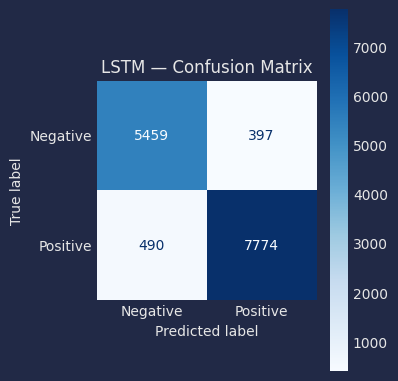

[[5459  397]
 [ 490 7774]]


In [48]:
true_lstm = []
pred_lstm = []

model.eval()
with torch.no_grad():
    for Xb, yb in valid_loader:
        Xb = Xb.to(device)

        logits = model(Xb)              # shape [batch, 1]
        preds = (logits >= 0).long()    # бинарное преобразование

        true_lstm.extend(yb.cpu().numpy())
        pred_lstm.extend(preds.cpu().numpy().reshape(-1))

# ====== CONFUSION MATRIX (единый стиль) ======
cm_lstm = plot_cm(true_lstm, pred_lstm, title="LSTM — Confusion Matrix")
print(cm_lstm)

In [49]:
print(df['sentiment'].value_counts())

sentiment
1    41419
0    29178
Name: count, dtype: int64


In [50]:
print("Vocab size:", len(vocab))
print("UNK:", vocab.get("<unk>"))
print("PAD:", vocab.get("<pad>"))

Vocab size: 15000
UNK: None
PAD: None


In [51]:
int_to_vocab = {idx: word for word, idx in vocab_to_int.items()}
sample = X_valid[0]   # numpy array
decoded = [int_to_vocab.get(int(i), "<unk>") for i in sample if i != 0]
print(decoded[:50])

['отличная', 'аптека.', 'покупал', 'лекарства', 'для', 'семьи.', 'очень', 'хороший', 'персонал.', 'лекарства', 'хорошего', 'качества.', 'в', 'общем,', 'отличная', 'аптека', 'для', 'лекарств.']


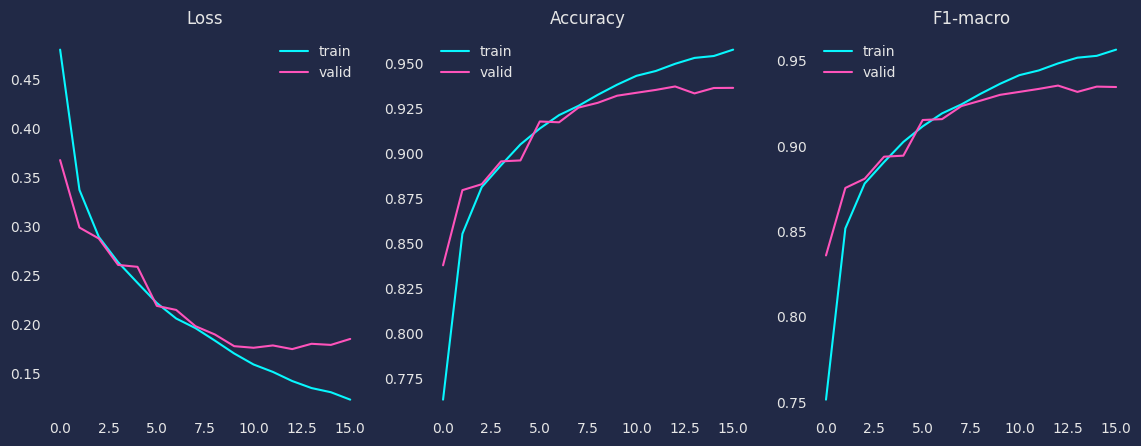

In [52]:
plt.figure(figsize=(14,5))

plt.subplot(1,3,1)
plt.plot(train_losses, label='train')
plt.plot(valid_losses, label='valid')
plt.title("Loss")
plt.grid()
plt.legend()

plt.subplot(1,3,2)
plt.plot(train_accs, label='train')
plt.plot(valid_accs, label='valid')
plt.title("Accuracy")
plt.grid()
plt.legend()

plt.subplot(1,3,3)
plt.plot(train_f1s, label='train')
plt.plot(valid_f1s, label='valid')
plt.title("F1-macro")
plt.grid()
plt.legend()

plt.show()

In [53]:
def preprocess(text: str, vocab_to_int: dict, seq_len: int = 200) -> torch.Tensor:
    text = clean_text(text)
    tokens = text.split()
    encoded = [vocab_to_int[w] for w in tokens if w in vocab_to_int]
    padded = padding_tail([encoded], seq_len)[0]
    return torch.tensor(padded).unsqueeze(0)  # shape: (1, seq_len)


def predict_review(text: str, model, vocab_to_int: dict, device, seq_len: int = 200):
    model.eval()
    inp = preprocess(text, vocab_to_int, seq_len).to(device)

    t0 = time.time()
    with torch.no_grad():
        logit = model(inp)
        prob = torch.sigmoid(logit).item()
    infer_ms = (time.time() - t0) * 1000.0  # Время в миллисекундах

    label = 1 if prob >= 0.5 else 0
    return label, prob, infer_ms


# пример
example_text = "рекомендую эту клинику"
label, prob, infer_ms = predict_review(example_text, model, vocab_to_int, device)
print(f"Text: {example_text}")
print(f"Prob(positive) = {prob:.4f}, label = {label}, infer = {infer_ms:.2f} ms")

Text: рекомендую эту клинику
Prob(positive) = 0.8125, label = 1, infer = 1.11 ms


## BERT

In [54]:
df = pd.read_json('data/healthcare_facilities_reviews.jsonl', lines=True)
df.head()

,review_id,category,title,content,sentiment,source_url
0,0,Поликлиники стоматологические,Классный мастер,Огромное спасибо за чудесное удаление двух зуб...,positive,http://www.spr.ru/forum_vyvod.php?id_tema=2727539
1,1,Поликлиники стоматологические,Замечательный врач,Хочу выразить особую благодарность замечательн...,positive,http://www.spr.ru/forum_vyvod.php?id_tema=2302877
2,2,Поликлиники стоматологические,Благодарность работникам рентгена,Добрый вечер! Хотелось бы поблагодарить сотруд...,positive,http://www.spr.ru/forum_vyvod.php?id_tema=2815031
3,3,Поликлиники стоматологические,Доктор Рабинович,Женщины советского образца в регистратуре не и...,negative,http://www.spr.ru/forum_vyvod.php?id_tema=3443161
4,4,Поликлиники стоматологические,Есть кому сказать спасибо,У меня с детства очень плохие зубы (тонкая и х...,positive,http://www.spr.ru/forum_vyvod.php?id_tema=2592430


In [55]:
# df = pd.read_json('/content/drive/MyDrive/healthcare_facilities_reviews.jsonl', lines=True)
# df.head()

In [56]:
def clean_text(text: str) -> str:
    text = re.sub("<.*?>", "", text)          # remove html
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_review"] = df["content"].apply(clean_text)
df["label"] = df["sentiment"].map({"positive": 1, "negative": 0})

In [57]:
X_train, X_val, y_train, y_val = train_test_split(
    df["clean_review"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print(len(X_train), len(X_val))

56477 14120


In [58]:
class ReviewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label": torch.tensor(self.labels[idx], dtype=torch.long)
        }

    def __len__(self):
        return len(self.labels)

In [59]:
MODEL_NAME = "ai-forever/ruBERT-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    output_attentions=True
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1622.06it/s, Materializing param=bert.pooler.dense.weight]                               
BertForSequenceClassification LOAD REPORT from: ai-forever/ruBERT-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPE

In [60]:
train_ds = ReviewsDataset(X_train.tolist(), y_train.tolist(), tokenizer)
val_ds   = ReviewsDataset(X_val.tolist(),   y_val.tolist(),   tokenizer)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

criterion = nn.CrossEntropyLoss()

In [61]:
model.bert.embeddings.dropout.p = 0.15
for layer in model.bert.encoder.layer:
    layer.output.dropout.p = 0.15
    layer.attention.output.dropout.p = 0.15

In [62]:
for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

for layer_i in [8, 9]:
    for param in model.bert.encoder.layer[layer_i].parameters():
        param.requires_grad = True

In [63]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5,             # мягкий learning rate → нет разрыва train/val
    weight_decay=0.01
)

In [64]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

In [65]:
from transformers import get_linear_schedule_with_warmup

num_training_steps = len(train_loader) * EPOCHS
num_warmup_steps = int(num_training_steps * 0.05)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

In [66]:
# === PARAM COUNT ===
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 178308866
Trainable parameters: 14177282


In [67]:
def train_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss = 0
    all_true, all_pred = [], []

    for batch in loader:
        ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        out = model(input_ids=ids, attention_mask=mask)
        logits = out.logits

        loss = criterion(logits, labels)
        loss.backward()

        # КЛЮЧ: подавляем скачки градиентов
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)

        all_true.extend(labels.cpu().numpy())
        all_pred.extend(preds.cpu().numpy())

    return (
        total_loss / len(loader.dataset),
        f1_score(all_true, all_pred, average="macro"),
        accuracy_score(all_true, all_pred)
    )


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_true, all_pred = [], []

    with torch.no_grad():
        for batch in loader:
            ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            out = model(input_ids=ids, attention_mask=mask)
            logits = out.logits

            loss = criterion(logits, labels)
            total_loss += loss.item() * labels.size(0)

            preds = logits.argmax(dim=1)

            all_true.extend(labels.cpu().numpy())
            all_pred.extend(preds.cpu().numpy())

    return (
        total_loss / len(loader.dataset),
        f1_score(all_true, all_pred, average="macro"),
        accuracy_score(all_true, all_pred)
    )

In [68]:
EPOCHS = 7
best_f1 = 0
best_state = None
metrics_history = []

t_global_start = time.time()

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_f1, tr_acc = train_epoch(model, train_loader, optimizer, scheduler, criterion, device)
    val_loss, val_f1, val_acc = eval_epoch(model, val_loader, criterion, device)

    t_epoch_end = time.time()
    epoch_time = t_epoch_end - t_epoch_start

    epoch_record = {
        "epoch": epoch,
        "train_loss": float(tr_loss),
        "train_f1": float(tr_f1),
        "train_acc": float(tr_acc),
        "val_loss": float(val_loss),
        "val_f1": float(val_f1),
        "val_acc": float(val_acc),
        "epoch_time_sec": float(epoch_time),
        "epoch_time_ms": float(epoch_time * 1000),
        "infer_time_ms_per_sample": float(infer_ms)
    }

    metrics_history.append(epoch_record)

    print(
        f"Epoch {epoch:02d} | "
        f"TrainLoss={tr_loss:.4f} Acc={tr_acc:.4f} F1={tr_f1:.4f} | "
        f"ValidLoss={val_loss:.4f} Acc={val_acc:.4f} F1={val_f1:.4f} | "
        f"Infer={infer_ms:.3f} ms/sample | "
        f"EpochTime={epoch_time:.2f} s |"
    )

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_state = model.state_dict()
        best_metrics = epoch_record

t_global_end = time.time()
total_train_time_sec = t_global_end - t_global_start

model.load_state_dict(best_state)

print("\nTraining finished.")
print(f"Total training time: {total_train_time_sec:.2f} sec")

Epoch 01 | TrainLoss=0.3422 Acc=0.8652 F1=0.8637 | ValidLoss=0.2087 Acc=0.9598 F1=0.9587 | Infer=1.106 ms/sample | EpochTime=196.80 s |
Epoch 02 | TrainLoss=0.2035 Acc=0.9606 F1=0.9595 | ValidLoss=0.1959 Acc=0.9659 F1=0.9650 | Infer=1.106 ms/sample | EpochTime=387.94 s |
Epoch 03 | TrainLoss=0.1913 Acc=0.9673 F1=0.9664 | ValidLoss=0.1925 Acc=0.9671 F1=0.9662 | Infer=1.106 ms/sample | EpochTime=580.40 s |
Epoch 04 | TrainLoss=0.1825 Acc=0.9717 F1=0.9709 | ValidLoss=0.1909 Acc=0.9686 F1=0.9676 | Infer=1.106 ms/sample | EpochTime=771.92 s |
Epoch 05 | TrainLoss=0.1751 Acc=0.9754 F1=0.9747 | ValidLoss=0.1934 Acc=0.9681 F1=0.9671 | Infer=1.106 ms/sample | EpochTime=963.81 s |
Epoch 06 | TrainLoss=0.1682 Acc=0.9791 F1=0.9785 | ValidLoss=0.1974 Acc=0.9698 F1=0.9690 | Infer=1.106 ms/sample | EpochTime=1156.16 s |
Epoch 07 | TrainLoss=0.1631 Acc=0.9812 F1=0.9806 | ValidLoss=0.1965 Acc=0.9704 F1=0.9695 | Infer=1.106 ms/sample | EpochTime=1348.38 s |

Training finished.
Total training time: 1341.

In [69]:
def measure_inference_time(model, loader, device):
    model.eval()
    total_time = 0
    total_samples = 0

    with torch.no_grad():
        for batch in loader:
            ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)

            start = time.time()
            _ = model(input_ids=ids, attention_mask=mask)
            end = time.time()

            total_time += (end - start)
            total_samples += ids.size(0)

    avg_sec = total_time / total_samples
    return avg_sec, avg_sec * 1000


infer_sec, infer_ms = measure_inference_time(model, val_loader, device)
best_metrics["infer_time_sec_per_sample"] = infer_sec
best_metrics["infer_time_ms_per_sample"] = infer_ms

best_metrics

{'epoch': 7,
 'train_loss': 0.16308413954932505,
 'train_f1': 0.9806157654548475,
 'train_acc': 0.9811781787276236,
 'val_loss': 0.19651143755183342,
 'val_f1': 0.9695384178676955,
 'val_acc': 0.9703966005665723,
 'epoch_time_sec': 1348.3796203136444,
 'epoch_time_ms': 1348379.6203136444,
 'infer_time_ms_per_sample': 0.41918052154627466,
 'infer_time_sec_per_sample': 0.00041918052154627465}

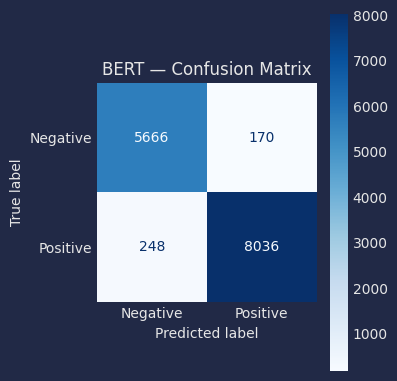

[[5666  170]
 [ 248 8036]]


In [70]:
true_bert = []
pred_bert = []

model.eval()
with torch.no_grad():
    for batch in val_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        # forward
        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).logits

        preds = logits.argmax(dim=1)

        true_bert.extend(labels.cpu().numpy())
        pred_bert.extend(preds.cpu().numpy())

# ====== CONFUSION MATRIX (единый стиль) ======
cm_bert = plot_cm(true_bert, pred_bert, title="BERT — Confusion Matrix")
print(cm_bert)

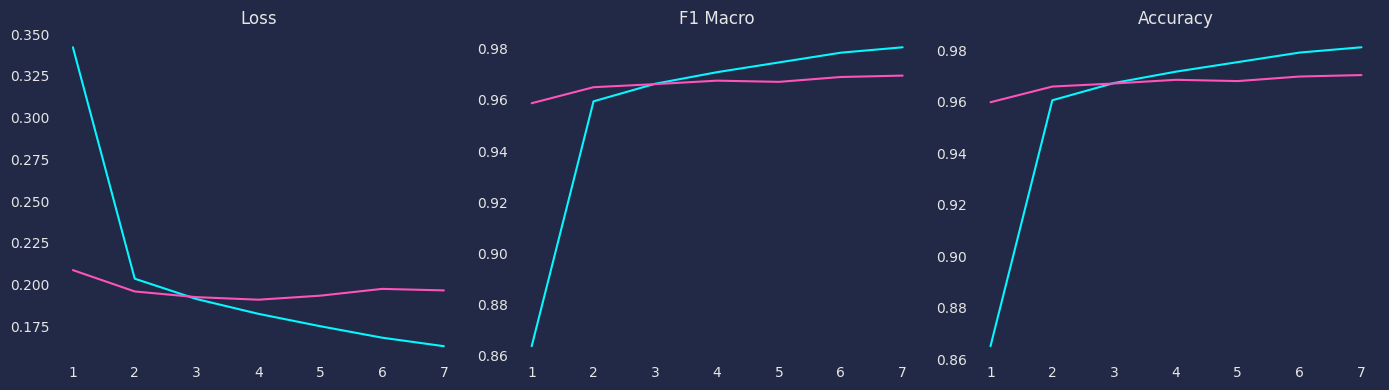

In [71]:
epochs = [m["epoch"] for m in metrics_history]

plt.figure(figsize=(14,4))

plt.subplot(1,3,1)
plt.plot(epochs, [m["train_loss"] for m in metrics_history])
plt.plot(epochs, [m["val_loss"] for m in metrics_history])
plt.title("Loss")
plt.grid()

plt.subplot(1,3,2)
plt.plot(epochs, [m["train_f1"] for m in metrics_history])
plt.plot(epochs, [m["val_f1"] for m in metrics_history])
plt.title("F1 Macro")
plt.grid()

plt.subplot(1,3,3)
plt.plot(epochs, [m["train_acc"] for m in metrics_history])
plt.plot(epochs, [m["val_acc"] for m in metrics_history])
plt.title("Accuracy")
plt.grid()

plt.tight_layout()
plt.show()

In [72]:
SAVE_DIR = "bert_ru_base_model"

model.load_state_dict(best_state)
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

with open(f"{SAVE_DIR}/metrics_history.json", "w") as f:
    json.dump(metrics_history, f, indent=4)

with open(f"{SAVE_DIR}/best_metrics.json", "w") as f:
    json.dump(best_metrics, f, indent=4)

experiment_config = {
    "model_name": MODEL_NAME,
    "epochs": EPOCHS,
    "train_size": len(train_ds),
    "val_size": len(val_ds),
    "total_train_time_sec": float(total_train_time_sec),
    "inference_time_ms_per_sample": float(infer_ms),
}

with open(f"{SAVE_DIR}/experiment_config.json", "w") as f:
    json.dump(experiment_config, f, indent=4)

print("Saved.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.90s/it]

Saved.


In [73]:
def get_attention_for_text(
    text: str,
    model,
    tokenizer,
    device,
    layer: int = -1  # по умолчанию последний слой
):
    model.eval()
    with torch.no_grad():
        enc = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding="max_length",
            max_length=256
        )

        input_ids = enc["input_ids"].to(device)
        attention_mask = enc["attention_mask"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_attentions=True
        )

        # outputs.attentions: список длиной = num_layers
        # каждый элемент: [batch, heads, seq_len, seq_len]
        attn_all_layers = outputs.attentions
        last_attn = attn_all_layers[layer]     
        # усредняем по головам
        # last_attn: [1, num_heads, seq_len, seq_len]
        avg_attn = last_attn.mean(dim=1)       # [1, seq_len, seq_len]

        # берем первую (и единственную) запись в батче
        attn_matrix = avg_attn[0]              # [seq_len, seq_len]

        # внимание от [CLS] (позиция 0) ко всем токенам
        cls_attn = attn_matrix[0]              # [seq_len]

        # превращаем ids → токены
        tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

        # учитываем реальную длину (по attention_mask)
        valid_len = int(attention_mask[0].sum().item())
        tokens = tokens[:valid_len]
        cls_attn = cls_attn[:valid_len]

        # вектор attention на CPU + numpy
        attn_vec = cls_attn.detach().cpu().numpy()

    return tokens, attn_vec

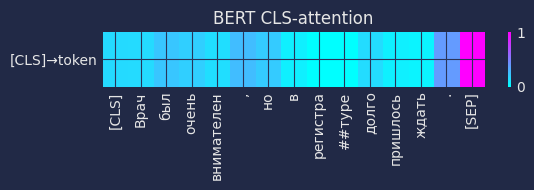

In [74]:
def plot_attention_heatmap(tokens, attn_vec, title="CLS attention"):
    # нормируем в [0,1] для стабильности
    attn_norm = (attn_vec - attn_vec.min()) / (attn_vec.max() - attn_vec.min() + 1e-8)

    plt.figure(figsize=(max(6, len(tokens) * 0.4), 2))
    plt.imshow(attn_norm[None, :], aspect="auto")
    plt.colorbar()
    plt.yticks([0], ["[CLS]→token"])
    plt.xticks(range(len(tokens)), tokens, rotation=90)
    plt.title(title)
    plt.tight_layout()
    plt.show()

# пример использования:
sample_text = "Врач был очень внимателен, но в регистратуре долго пришлось ждать."
tokens, attn_vec = get_attention_for_text(sample_text, model, tokenizer, device)
plot_attention_heatmap(tokens, attn_vec, title="BERT CLS-attention")

In [75]:
# ============================================================
# 15. HTML-подсветка токенов по attention (для Streamlit)
# ============================================================

def attention_to_html(tokens, attn_vec):
    """
    Возвращает HTML-строку с токенами, подсвеченными по силе attention.
    Можно использовать в Streamlit: st.markdown(html, unsafe_allow_html=True)
    """

    # нормируем в [0,1]
    attn_norm = (attn_vec - attn_vec.min()) / (attn_vec.max() - attn_vec.min() + 1e-8)

    html_tokens = []
    for tok, score in zip(tokens, attn_norm):
        # немного сгладим яркость
        alpha = float(score)
        # легкий градиент от белого к оранжевому
        color = f"rgba(255, 165, 0, {alpha:.2f})"
        tok_clean = tok.replace("▁", "")  
        if tok_clean == "":
            tok_clean = tok  # fallback

        span = f'<span style="background-color:{color}; padding:2px; margin:1px; border-radius:3px;">{tok_clean}</span>'
        html_tokens.append(span)

    html = "<div>" + " ".join(html_tokens) + "</div>"
    return html

# Пример: получить HTML и посмотреть его прямо в ноутбуке (в Jupyter)
from IPython.core.display import HTML

sample_text = "Доктор всё объяснил подробно, но в очереди было слишком много людей."
tokens, attn_vec = get_attention_for_text(sample_text, model, tokenizer, device)
html = attention_to_html(tokens, attn_vec)
HTML(html)

In [ ]:
results.append({
    "model": "BERT (ruBERT-tiny2 head)",

    "train_loss": float(best_metrics["train_loss"]),
    "train_f1": float(best_metrics["train_f1"]),
    "train_acc": float(best_metrics["train_acc"]),

    "val_loss": float(best_metrics["val_loss"]),
    "val_f1": float(best_metrics["val_f1"]),
    "val_acc": float(best_metrics["val_acc"]),

    "infer_time_sec_per_sample": float(best_metrics.get("infer_time_sec_per_sample", 0)),
    "train_time_sec": float(total_train_time_sec), 

    "best_epoch": best_metrics["epoch"],
})

In [77]:
results

[{'model': 'TFIDF_LogReg',
  'train_loss': 0.14884579579472304,
  'train_f1': 0.9625329913943121,
  'train_acc': 0.9634364431538502,
  'val_loss': 0.171071994968024,
  'val_f1': 0.945357130942452,
  'val_acc': 0.946600566572238,
  'infer_time_sec_per_sample': 0.5756235122680664,
  'train_time_sec': 17.504666805267334},
 {'model': 'LSTM_review',
  'train_loss': 0.14236792820651514,
  'train_f1': 0.9484420706730814,
  'train_acc': 0.9498830782312925,
  'val_loss': 0.17487568341128462,
  'val_f1': 0.9354460804419036,
  'val_acc': 0.9372606980908025,
  'infer_time_sec_per_sample': 0.010316946646647143,
  'train_time_sec': 42979.66003417969},
 {'model': 'BERT (ruBERT-tiny2 head)',
  'train_loss': 0.16308413954932505,
  'train_f1': 0.9806157654548475,
  'train_acc': 0.9811781787276236,
  'val_loss': 0.19651143755183342,
  'val_f1': 0.9695384178676955,
  'val_acc': 0.9703966005665723,
  'infer_time_sec_per_sample': 0.00041918052154627465,
  'train_time_sec': 1341412.6482009888,
  'best_epoch'

In [78]:
df_results = pd.DataFrame(results)
df_results

,model,train_loss,train_f1,train_acc,val_loss,val_f1,val_acc,infer_time_sec_per_sample,train_time_sec,best_epoch
0,TFIDF_LogReg,0.148846,0.962533,0.963436,0.171072,0.945357,0.946601,0.575624,1.750467e+01,NaN
1,LSTM_review,0.142368,0.948442,0.949883,0.174876,0.935446,0.937261,0.010317,4.297966e+04,NaN
2,BERT (ruBERT-tiny2 head),0.163084,0.980616,0.981178,0.196511,0.969538,0.970397,0.000419,1.341413e+06,7.0


In [79]:
df_results = pd.DataFrame(results)

cols_to_drop = ["infer_time_sec_per_sample", "best_epoch"]
df_results = df_results.drop(columns=[c for c in cols_to_drop if c in df_results.columns])

In [80]:
df_formatted_time = df_results.copy()

float4 = ["train_loss", "train_f1", "train_acc",
          "val_loss", "val_f1", "val_acc"]

for col in float4:
    if col in df_formatted_time.columns:
        df_formatted_time[col] = df_formatted_time[col].map(lambda x: f"{x:.4f}")

if "train_time_sec" in df_formatted_time.columns:
    df_formatted_time["train_time_sec"] = df_formatted_time["train_time_sec"].map(lambda x: f"{x:.2f} s")

In [81]:
df_formatted_time

,model,train_loss,train_f1,train_acc,val_loss,val_f1,val_acc,train_time_sec
0,TFIDF_LogReg,0.1488,0.9625,0.9634,0.1711,0.9454,0.9466,17.50 s
1,LSTM_review,0.1424,0.9484,0.9499,0.1749,0.9354,0.9373,42979.66 s
2,BERT (ruBERT-tiny2 head),0.1631,0.9806,0.9812,0.1965,0.9695,0.9704,1341412.65 s


In [82]:
df_formatted_time = df_formatted_time.rename(
    columns={"train_time_sec": "total_time_sec"}
)

In [83]:
def predict_review_bert(text: str, model, tokenizer, device, max_len: int = 256):
    model.eval()

    # Токенизация
    enc = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=max_len,
        return_tensors="pt"
    )

    input_ids     = enc["input_ids"].to(device)
    attention_mask = enc["attention_mask"].to(device)

    # Замер времени
    t0 = time.time()
    with torch.no_grad():
        logits = model(input_ids, attention_mask)
        prob = torch.softmax(logits, dim=1)[0, 1].item()   # класс 1 — positive

    infer_ms = (time.time() - t0) * 1000.0  # инференс в миллисекундах

    label = 1 if prob >= 0.5 else 0

    return label, prob, infer_ms

In [84]:
example_text = "рекомендую эту клинику"

label, prob, infer_ms = predict_review_bert(
    example_text,
    model,      # твой BERT-классификатор
    tokenizer,
    device
)

print(f"Text: {example_text}")
print(f"Prob(positive) = {prob:.4f}, label = {label}, infer = {infer_ms:.2f} ms")

TypeError: softmax() received an invalid combination of arguments - got (SequenceClassifierOutput, dim=int), but expected one of:
 * (Tensor input, int dim, torch.dtype dtype = None, *, Tensor out = None)
 * (Tensor input, name dim, *, torch.dtype dtype = None)


In [ ]:
df_formatted_time

,model,train_loss,train_f1,train_acc,val_loss,val_f1,val_acc,total_time_sec
0,TFIDF_LogReg,0.1488,0.9624,0.9633,0.1711,0.9452,0.9465,22.15 s
1,LSTM_review,0.1300,0.9538,0.9551,0.1663,0.9380,0.9397,123898.47 s
2,BERT (ruBERT-tiny2 head),0.1585,0.9380,0.9397,0.1587,0.9409,0.9421,686110.87 s
